# Stress-Test Experiments

Five experiments designed to push the physics discovery pipeline to its limits.
Each tests a scenario where naive experiment design or simple curve-fitting would fail.

| # | Experiment | Engine | Key challenge |
|---|-----------|--------|---------------|
| 1 | Screened $1/r^2$ | N-body | Exponential suppression hidden at short range |
| 2 | Hidden charges | FieldSampler | Latent binary variable changes coupling sign/magnitude |
| 3 | Dark particles | FieldSampler | Invisible particles break apparent momentum conservation |
| 4 | Running coupling | N-body | Scale-dependent $g(r)$ mimics different power laws at different $r$ |
| 5 | 2D Yukawa | FieldSampler | Screened Poisson PDE; comparison with experiment 1 |

In [10]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from scipy.special import kv as besselk
from physchool.worlds.field_sampler import FieldSampler
from physchool.env import _run_single_experiment, WorldConfig

%matplotlib inline
plt.rcParams.update({'font.size': 13})


# ---------------------------------------------------------------------------
# Direct N-body integrator (leapfrog) for arbitrary pairwise force laws
# ---------------------------------------------------------------------------

def nbody_simulate(positions, velocities, masses, force_fn, dt, n_steps,
                   measurement_times=None, labels=None):
    """Leapfrog N-body integrator with arbitrary pairwise forces.

    Parameters
    ----------
    positions : (N, 2) array
    velocities : (N, 2) array
    masses : (N,) array — used as inertia for F = m*a
    force_fn : callable(r_vec, r_mag, m_i, m_j, label_i, label_j) -> (2,) force on i from j
    dt : float
    n_steps : int
    measurement_times : list[float] or None
    labels : (N,) array or None — extra per-particle attribute passed to force_fn

    Returns
    -------
    dict with keys 'measurement_times', 'positions', 'velocities'
    (same shape convention as _run_single_experiment)
    """
    pos = positions.astype(np.float64).copy()
    vel = velocities.astype(np.float64).copy()
    n = len(pos)
    if labels is None:
        labels = np.ones(n)
    time = 0.0

    if measurement_times is None:
        measurement_times = [n_steps * dt]
    measurement_times = sorted(measurement_times)

    rec_pos = [[] for _ in range(n)]
    rec_vel = [[] for _ in range(n)]
    t_idx = 0

    def _record():
        for i in range(n):
            rec_pos[i].append(pos[i].tolist())
            rec_vel[i].append(vel[i].tolist())

    if measurement_times[0] == 0.0:
        _record()
        t_idx = 1

    def _compute_forces():
        forces = np.zeros_like(pos)
        for i in range(n):
            for j in range(i + 1, n):
                r_vec = pos[i] - pos[j]
                r_mag = np.linalg.norm(r_vec)
                if r_mag < 1e-12:
                    continue
                f_ij = force_fn(r_vec, r_mag, masses[i], masses[j],
                                labels[i], labels[j])
                forces[i] += f_ij
                forces[j] -= f_ij
            forces[i] /= masses[i]  # acceleration
        return forces  # actually accelerations

    # Leapfrog: kick-drift (matches FieldSampler convention)
    for _ in range(n_steps):
        if t_idx >= len(measurement_times):
            break
        acc = _compute_forces()
        vel += dt * acc
        pos += dt * vel
        time += dt

        if time >= measurement_times[t_idx] - dt * 0.5:
            _record()
            t_idx += 1

    return {
        'measurement_times': measurement_times[:len(rec_pos[0])],
        'positions': rec_pos,
        'velocities': rec_vel,
    }


def measure_nbody_force_vs_sep(force_fn, separations, m1=1.0, m2=1.0,
                                label1=1.0, label2=1.0):
    """Measure the radial force magnitude at a set of pair separations."""
    forces = []
    for sep in separations:
        r_vec = np.array([sep, 0.0])
        f = force_fn(r_vec, sep, m1, m2, label1, label2)
        forces.append(-f[0])  # radial component (attractive → positive)
    return np.array(forces)

## Experiment 1 — Exponentially screened inverse-square force

$$F = \frac{G\, m_i\, m_j}{r^2}\, e^{-r/\lambda}$$

At short range ($r \ll \lambda$) this is indistinguishable from a standard $1/r^2$ law.
The exponential suppression only shows up at $r \gtrsim \lambda$, so an agent
that only runs short-range experiments will never detect the screening length.

This force law does **not** correspond to any linear PDE Green's function:
- 2D screened Poisson (experiment 5) gives $F \sim K_1(r/\lambda)/\lambda$, with a $1/\!\sqrt{r}$ prefactor at large $r$
- 3D Yukawa gives $F \sim (1/r^2 + 1/(r\lambda))\, e^{-r/\lambda}$ — extra $1/(r\lambda)$ term

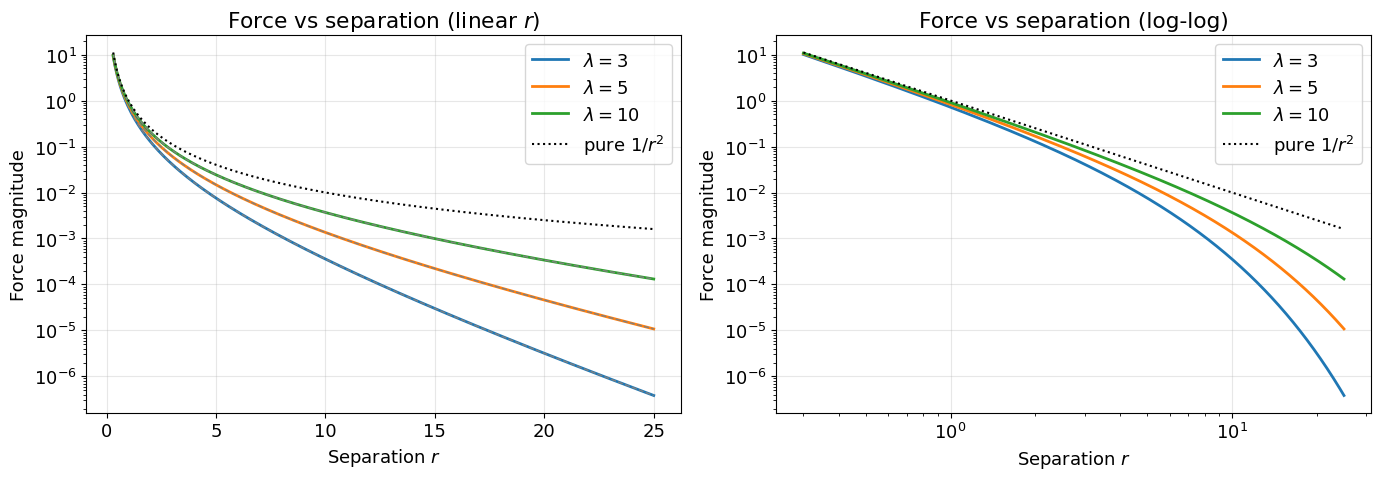

In [27]:
G_scr = 1.0
eps_soft = 0.1

def screened_inv_sq_force(r_vec, r_mag, m_i, m_j, label_i, label_j,
                          lam=5.0):
    """F = G * m_i * m_j / r^2 * exp(-r/lambda), attractive, with softening."""
    F_mag = G_scr * m_i * m_j / (r_mag**2 + eps_soft**2) * np.exp(-r_mag / lam)
    return -F_mag * r_vec / r_mag  # points from i toward j

# --- Force vs separation for several lambda values ---
seps = np.linspace(0.3, 25.0, 300)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for lam in [3, 5, 10]:
    force_fn = lambda rv, rm, mi, mj, li, lj, _l=lam: screened_inv_sq_force(
        rv, rm, mi, mj, li, lj, lam=_l)
    F_meas = measure_nbody_force_vs_sep(force_fn, seps)
    F_theory = G_scr / seps**2 * np.exp(-seps / lam)
    axes[0].plot(seps, F_meas, '-', lw=2, label=f'$\\lambda={lam}$')
    axes[0].plot(seps, F_theory, '--', lw=1, color='gray')

F_pure = G_scr / seps**2
axes[0].plot(seps, F_pure, 'k:', lw=1.5, label='pure $1/r^2$')
axes[0].set_xlabel('Separation $r$')
axes[0].set_ylabel('Force magnitude')
axes[0].set_yscale('log')
axes[0].set_title('Force vs separation (linear $r$)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for lam in [3, 5, 10]:
    F_theory = G_scr / seps**2 * np.exp(-seps / lam)
    axes[1].plot(seps, F_theory, '-', lw=2, label=f'$\\lambda={lam}$')
axes[1].plot(seps, F_pure, 'k:', lw=1.5, label='pure $1/r^2$')
axes[1].set_xlabel('Separation $r$')
axes[1].set_ylabel('Force magnitude')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Force vs separation (log-log)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

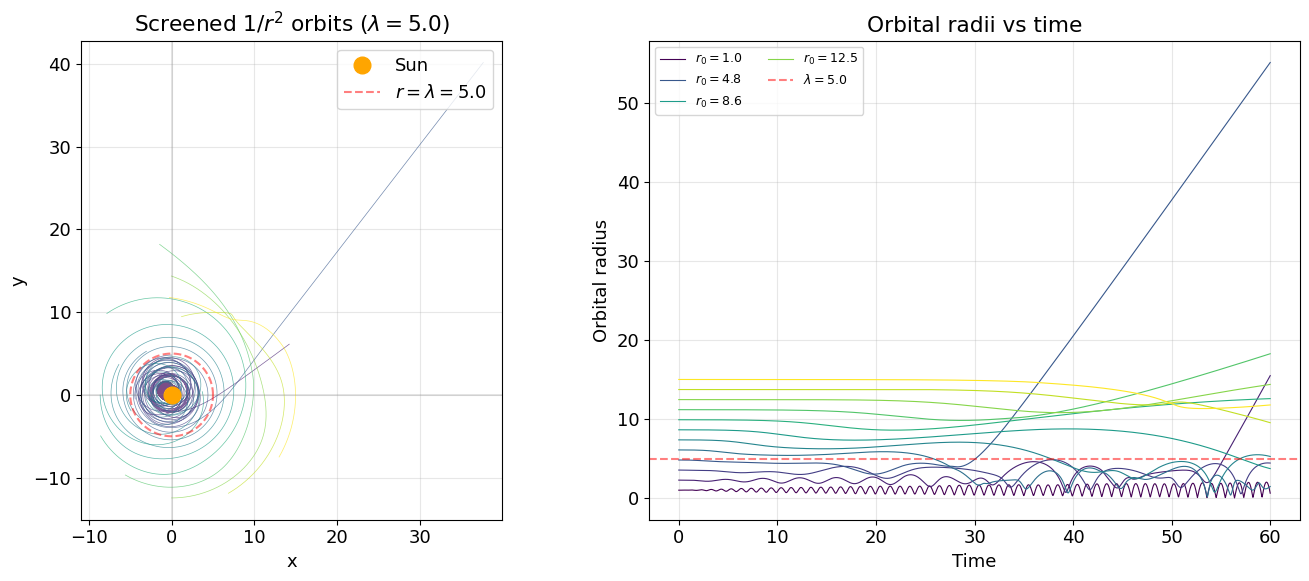

Inner planets (r << lambda) maintain stable orbits.
Outer planets (r >> lambda) feel almost no force and drift away.


In [28]:
# --- Orbital demo: sun + planets at various radii ---
lam_orbit = 5.0
M_sun = 50.0
m_planet = 0.1
n_planets = 12
dt_orb = 0.002
n_steps_orb = 30000

radii = np.linspace(1.0, 15.0, n_planets)
angles = np.linspace(0, 2 * np.pi, n_planets, endpoint=False)

positions_orb = np.zeros((1 + n_planets, 2))
velocities_orb = np.zeros((1 + n_planets, 2))
masses_orb = np.concatenate([[M_sun], np.full(n_planets, m_planet)])

for idx in range(n_planets):
    r = radii[idx]
    positions_orb[1 + idx] = [r * np.cos(angles[idx]), r * np.sin(angles[idx])]
    # v_circ from F = mv^2/r → v = sqrt(F*r/m)
    F_r = G_scr * M_sun * m_planet / r**2 * np.exp(-r / lam_orbit)
    v_circ = np.sqrt(F_r * r / m_planet)
    velocities_orb[1 + idx] = v_circ * np.array([-np.sin(angles[idx]),
                                                    np.cos(angles[idx])])

force_fn_orb = lambda rv, rm, mi, mj, li, lj: screened_inv_sq_force(
    rv, rm, mi, mj, li, lj, lam=lam_orbit)

result_orb = nbody_simulate(
    positions_orb, velocities_orb, masses_orb, force_fn_orb,
    dt=dt_orb, n_steps=n_steps_orb,
    measurement_times=[0.0] + list(np.arange(dt_orb, n_steps_orb * dt_orb, dt_orb * 10)),
)

traj = np.array(result_orb['positions'])  # (n_particles, n_times, 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = plt.cm.viridis(np.linspace(0, 1, n_planets))

ax = axes[0]
ax.plot(0, 0, 'o', ms=12, color='orange', zorder=10, label='Sun')
for idx in range(n_planets):
    t = traj[1 + idx]
    ax.plot(t[:, 0], t[:, 1], '-', lw=0.5, alpha=0.7, color=colors[idx])
ax.axhline(0, color='gray', lw=0.3)
ax.axvline(0, color='gray', lw=0.3)
theta_circle = np.linspace(0, 2 * np.pi, 100)
ax.plot(lam_orbit * np.cos(theta_circle), lam_orbit * np.sin(theta_circle),
        'r--', lw=1.5, alpha=0.5, label=f'$r = \\lambda = {lam_orbit}$')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title(f'Screened $1/r^2$ orbits ($\\lambda={lam_orbit}$)')
ax.set_aspect('equal')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

ax = axes[1]
times_orb = np.array(result_orb['measurement_times'])
for idx in range(n_planets):
    t = traj[1 + idx]
    r_t = np.linalg.norm(t, axis=1)
    ax.plot(times_orb[:len(r_t)], r_t, '-', lw=0.8, color=colors[idx],
            label=f'$r_0={radii[idx]:.1f}$' if idx % 3 == 0 else None)
ax.axhline(lam_orbit, color='r', ls='--', lw=1.5, alpha=0.5, label=f'$\\lambda={lam_orbit}$')
ax.set_xlabel('Time'); ax.set_ylabel('Orbital radius')
ax.set_title('Orbital radii vs time')
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Inner planets (r << lambda) maintain stable orbits.")
print("Outer planets (r >> lambda) feel almost no force and drift away.")

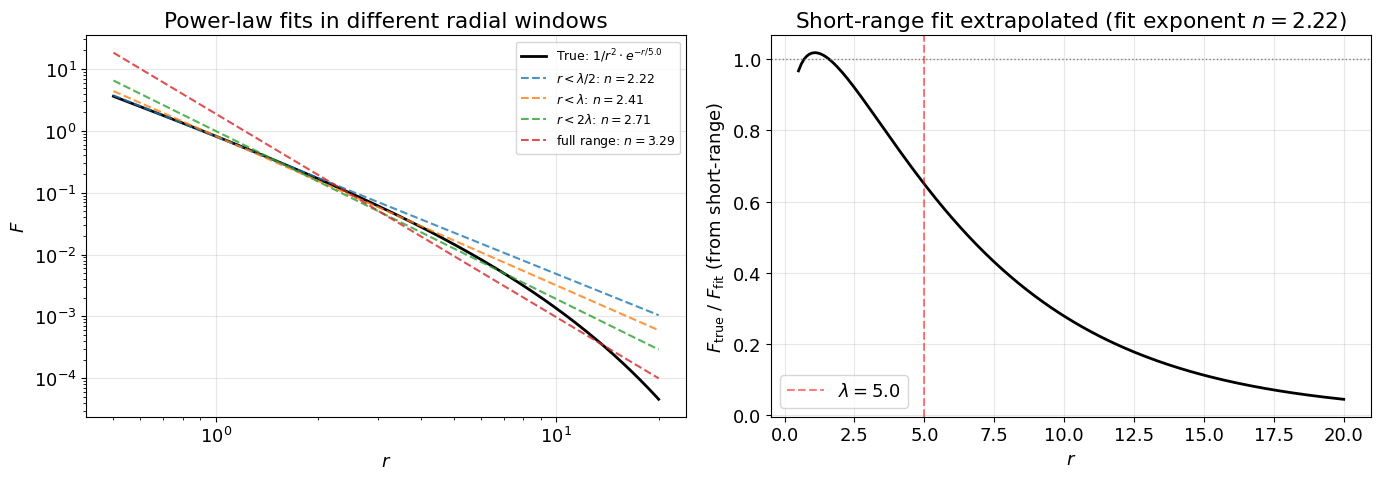

Short-range fit (r < lambda/2): exponent = 2.218 (true = 2.0)
At r = 3*lambda = 15.0: true/fit ratio = 0.1115
→ The screening is invisible unless you probe r > lambda.


In [13]:
# --- Discoverability analysis ---
# Fit power law 1/r^n to force data restricted to different radial windows.
# An agent probing only r < lambda/2 should recover n~2 with no hint of screening.

lam_disc = 5.0
r_all = np.linspace(0.5, 20.0, 200)
F_all = G_scr / r_all**2 * np.exp(-r_all / lam_disc)

windows = [
    (0.5, 2.0, '$r < \\lambda/2$'),
    (0.5, 5.0, '$r < \\lambda$'),
    (0.5, 10.0, '$r < 2\\lambda$'),
    (0.5, 20.0, 'full range'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(r_all, F_all, 'k-', lw=2, label=f'True: $1/r^2 \\cdot e^{{-r/{lam_disc}}}$')

for r_min, r_max, label in windows:
    mask = (r_all >= r_min) & (r_all <= r_max)
    log_r = np.log(r_all[mask])
    log_F = np.log(F_all[mask])
    slope, intercept = np.polyfit(log_r, log_F, 1)
    F_fit = np.exp(intercept) * r_all**slope
    ax.plot(r_all, F_fit, '--', lw=1.5, alpha=0.8,
            label=f'{label}: $n = {-slope:.2f}$')

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('$r$'); ax.set_ylabel('$F$')
ax.set_title('Power-law fits in different radial windows')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
# Residuals: ratio of true force to best-fit power law from short-range data
mask_short = (r_all >= 0.5) & (r_all <= 2.0)
slope_short, int_short = np.polyfit(np.log(r_all[mask_short]),
                                     np.log(F_all[mask_short]), 1)
F_fit_short = np.exp(int_short) * r_all**slope_short
ax.plot(r_all, F_all / F_fit_short, 'k-', lw=2)
ax.axhline(1.0, color='gray', ls=':', lw=1)
ax.axvline(lam_disc, color='r', ls='--', lw=1.5, alpha=0.5, label=f'$\\lambda={lam_disc}$')
ax.set_xlabel('$r$')
ax.set_ylabel('$F_{\\rm true}$ / $F_{\\rm fit}$ (from short-range)')
ax.set_title(f'Short-range fit extrapolated (fit exponent $n={-slope_short:.2f}$)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Short-range fit (r < lambda/2): exponent = {-slope_short:.3f} (true = 2.0)")
print(f"At r = 3*lambda = {3*lam_disc}: true/fit ratio = "
      f"{F_all[np.argmin(np.abs(r_all - 3*lam_disc))] / F_fit_short[np.argmin(np.abs(r_all - 3*lam_disc))]:.4f}")
print("→ The screening is invisible unless you probe r > lambda.")

## Experiment 2a — Hidden charges (single field, anti-electrostatic)

Particles all have the same mass $m=1$, but carry a hidden binary charge $q = \pm 1$.
A single Poisson field sourced by charge gives $F \propto q_i\, q_j / r$:
- **Same-sign** charges **attract** (gravity-like)
- **Opposite-sign** charges **repel**

The agent sees particles with identical observable "mass" yet some pairs attract
and others repel.  Without discovering the latent charge variable, the force
measurements look wildly inconsistent — possibly just noise.

In [14]:
# --- 2a setup: 8 particles with hidden +/- charges ---
rng = np.random.RandomState(42)
n_charge = 8
domain_ch = 40.0
center_ch = domain_ch / 2
grid_ch = 128
dt_ch = 0.005

charges = np.array([+1, -1, +1, +1, -1, -1, +1, -1], dtype=np.float64)
masses_ch = np.ones(n_charge)

# Random initial positions (centered) and small random velocities
pos_ch = rng.uniform(-6, 6, size=(n_charge, 2))
vel_ch = rng.uniform(-0.3, 0.3, size=(n_charge, 2))
vel_ch -= vel_ch.mean(axis=0)  # zero total momentum

ops_ch = [{'type': 'laplacian', 'params': {'strength': 1.0}}]

# FieldSampler with DECOUPLED inertia vs source/force
sim_ch = FieldSampler(
    particle_inertia=masses_ch,
    particle_source=charges,
    particle_force=charges,
    initial_positions=(pos_ch + center_ch).copy(),
    initial_velocities=vel_ch.copy(),
    spatial_dimensions=2,
    temporal_order=0,
    grid_size=(grid_ch, grid_ch),
    domain_size=domain_ch,
    operators=ops_ch,
    n_particles=n_charge,
    force_law='gradient',
    dt=dt_ch,
    source_coupling=charges,
    force_coupling=1.0,
    periodic_boundaries=False,
)

# Measure initial forces
forces_ch = sim_ch.step()
# Reset after measurement
sim_ch.positions = (pos_ch + center_ch).copy()
sim_ch.velocities = vel_ch.copy()
sim_ch.time = 0.0

print("Particle charges:", charges)
print("\nInitial forces on each particle:")
for i in range(n_charge):
    f = np.array(forces_ch[i])
    print(f"  Particle {i} (q={charges[i]:+.0f}): F = [{f[0]:+.4f}, {f[1]:+.4f}], |F| = {np.linalg.norm(f):.4f}")

Particle charges: [ 1. -1.  1.  1. -1. -1.  1. -1.]

Initial forces on each particle:
  Particle 0 (q=+1): F = [-0.0394, +0.0241], |F| = 0.0462
  Particle 1 (q=-1): F = [-0.0481, +0.0629], |F| = 0.0792
  Particle 2 (q=+1): F = [-0.1337, -0.1471], |F| = 0.1988
  Particle 3 (q=+1): F = [+0.0493, -0.0958], |F| = 0.1077
  Particle 4 (q=-1): F = [+0.0791, -0.0570], |F| = 0.0975
  Particle 5 (q=-1): F = [-0.0524, +0.1052], |F| = 0.1175
  Particle 6 (q=+1): F = [+0.0106, -0.0406], |F| = 0.0419
  Particle 7 (q=-1): F = [+0.1347, +0.1483], |F| = 0.2003


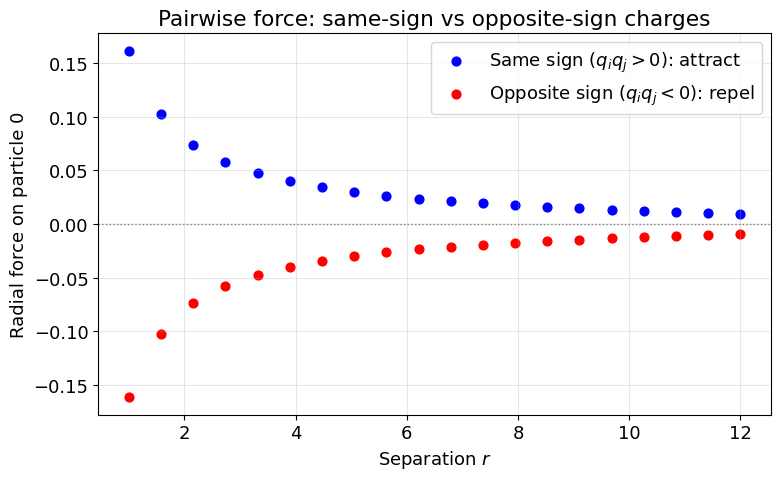

Without knowing the charge labels, these two branches look like noisy scatter.


In [15]:
# --- Force scatter plot: measure pairwise force magnitudes vs separation ---
# Use separate 2-particle sims to get clean pairwise measurements.

seps_test = np.linspace(1.0, 12.0, 20)
F_same, F_opp = [], []
r_same, r_opp = [], []

for sep in seps_test:
    for q1, q2, store_F, store_r in [(+1, +1, F_same, r_same),
                                      (+1, -1, F_opp, r_opp)]:
        p = np.array([[center_ch - sep / 2, center_ch],
                       [center_ch + sep / 2, center_ch]])
        v = np.zeros((2, 2))
        qs = np.array([q1, q2], dtype=np.float64)
        ms = np.ones(2)

        sim2 = FieldSampler(
            particle_inertia=ms, particle_source=qs, particle_force=qs,
            initial_positions=p.copy(), initial_velocities=v.copy(),
            spatial_dimensions=2, temporal_order=0,
            grid_size=(grid_ch, grid_ch), domain_size=domain_ch,
            operators=ops_ch, n_particles=2, force_law='gradient',
            dt=dt_ch, source_coupling=qs, force_coupling=1.0,
            periodic_boundaries=False,
        )
        f = sim2.step()
        # Radial force on particle 0 (positive = attractive = toward particle 1)
        r_hat = np.array([1.0, 0.0])
        f_rad = float(jnp.dot(f[0], r_hat))
        store_F.append(f_rad)
        store_r.append(sep)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(r_same, F_same, c='blue', s=40, label='Same sign ($q_i q_j > 0$): attract')
ax.scatter(r_opp, F_opp, c='red', s=40, label='Opposite sign ($q_i q_j < 0$): repel')
ax.axhline(0, color='gray', ls=':', lw=1)
ax.set_xlabel('Separation $r$')
ax.set_ylabel('Radial force on particle 0')
ax.set_title('Pairwise force: same-sign vs opposite-sign charges')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Without knowing the charge labels, these two branches look like noisy scatter.")

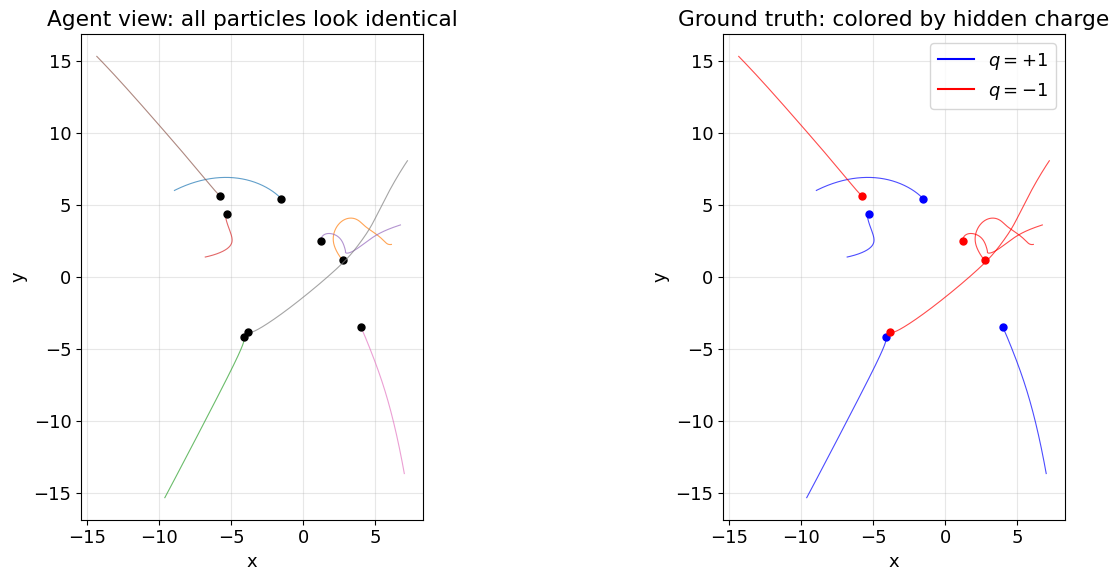

In [16]:
# --- Trajectory plot for 2a ---
n_steps_ch = 4000
sim_ch2 = FieldSampler(
    particle_inertia=masses_ch, particle_source=charges, particle_force=charges,
    initial_positions=(pos_ch + center_ch).copy(),
    initial_velocities=vel_ch.copy(),
    spatial_dimensions=2, temporal_order=0,
    grid_size=(grid_ch, grid_ch), domain_size=domain_ch,
    operators=ops_ch, n_particles=n_charge, force_law='gradient', dt=dt_ch,
    source_coupling=charges, force_coupling=1.0, periodic_boundaries=False,
)

traj_ch = np.zeros((n_steps_ch + 1, n_charge, 2))
traj_ch[0] = sim_ch2.positions - center_ch
for step in range(n_steps_ch):
    sim_ch2.step()
    traj_ch[step + 1] = sim_ch2.positions - center_ch

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: what the agent sees (no charge info)
ax = axes[0]
for i in range(n_charge):
    ax.plot(traj_ch[:, i, 0], traj_ch[:, i, 1], '-', lw=0.8, alpha=0.7)
    ax.plot(traj_ch[0, i, 0], traj_ch[0, i, 1], 'ko', ms=5)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Agent view: all particles look identical')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)

# Right: colored by charge
ax = axes[1]
for i in range(n_charge):
    color = 'blue' if charges[i] > 0 else 'red'
    ax.plot(traj_ch[:, i, 0], traj_ch[:, i, 1], '-', lw=0.8, alpha=0.7, color=color)
    ax.plot(traj_ch[0, i, 0], traj_ch[0, i, 1], 'o', ms=5, color=color)
ax.plot([], [], 'b-', label='$q = +1$')
ax.plot([], [], 'r-', label='$q = -1$')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Ground truth: colored by hidden charge')
ax.set_aspect('equal'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Experiment 2b — Two-field charges (both attract, different coefficients)

Same-label pairs attract with coupling $G_{\rm same}$, opposite-label with $G_{\rm opp}$
(both **positive**, different magnitudes).  Decompose into two fields:
- "Gravity" field: all particles source with $|q|$ → universal attraction, coupling $G_{\rm grav} = (G_{\rm same} + G_{\rm opp})/2$
- "Electric" field: particles source with $q$ → same-sign boost, opposite-sign penalty, coupling $G_{\rm elec} = (G_{\rm same} - G_{\rm opp})/2$

This is harder than 2a: all pairs attract, but the scatter in force magnitudes at fixed $r$ has two branches that are both positive.

G_same = 1.0, G_opp = 0.3
G_grav = 0.65, G_elec = 0.35
Check: G_grav + G_elec = 1.0 (should be 1.0)
Check: G_grav - G_elec = 0.30000000000000004 (should be 0.3)


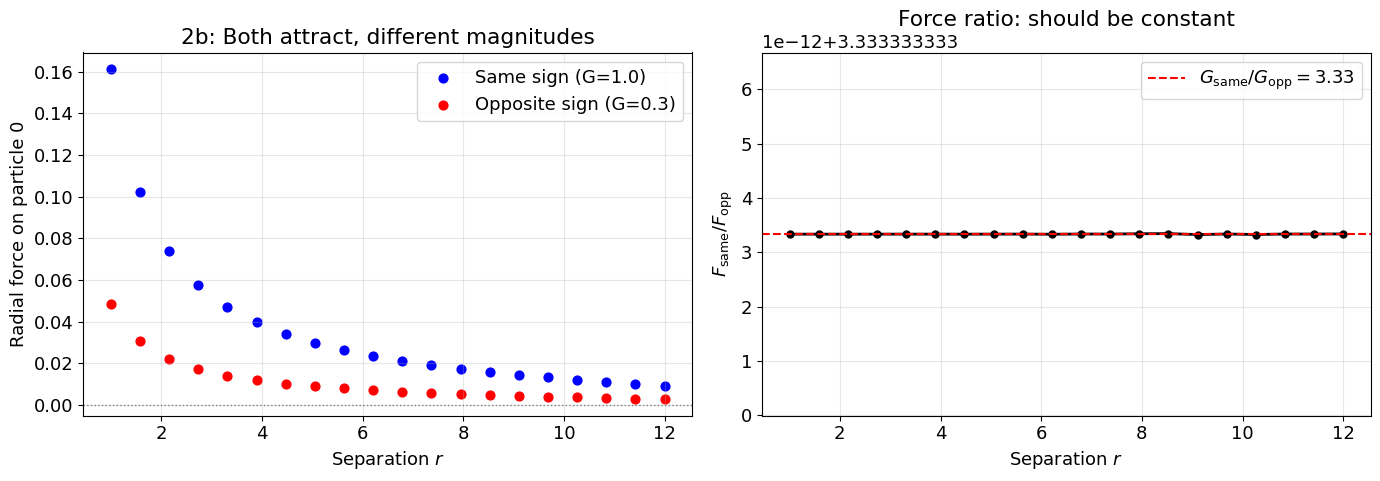

In [17]:
# --- 2b: Two-field charges with G_same=1.0, G_opp=0.3 ---
G_same = 1.0
G_opp = 0.3
G_grav = (G_same + G_opp) / 2  # 0.65
G_elec = (G_same - G_opp) / 2  # 0.35

print(f"G_same = {G_same}, G_opp = {G_opp}")
print(f"G_grav = {G_grav}, G_elec = {G_elec}")
print(f"Check: G_grav + G_elec = {G_grav + G_elec} (should be {G_same})")
print(f"Check: G_grav - G_elec = {G_grav - G_elec} (should be {G_opp})")

# Pairwise force measurements using two FieldSampler instances
seps_2b = np.linspace(1.0, 12.0, 20)
F_same_2b, F_opp_2b = [], []
r_same_2b, r_opp_2b = [], []

for sep in seps_2b:
    for q1, q2, store_F, store_r in [(+1, +1, F_same_2b, r_same_2b),
                                      (+1, -1, F_opp_2b, r_opp_2b)]:
        p = np.array([[center_ch - sep / 2, center_ch],
                       [center_ch + sep / 2, center_ch]])
        v = np.zeros((2, 2))
        qs = np.array([q1, q2], dtype=np.float64)
        abs_qs = np.abs(qs)
        ms = np.ones(2)

        # Gravity field (all source with |q|)
        sim_g = FieldSampler(
            particle_inertia=ms, particle_source=abs_qs, particle_force=abs_qs,
            initial_positions=p.copy(), initial_velocities=v.copy(),
            spatial_dimensions=2, temporal_order=0,
            grid_size=(grid_ch, grid_ch), domain_size=domain_ch,
            operators=ops_ch, n_particles=2, force_law='gradient', dt=dt_ch,
            source_coupling=abs_qs, force_coupling=G_grav, periodic_boundaries=False,
        )
        # Electric field (source with signed q)
        sim_e = FieldSampler(
            particle_inertia=ms, particle_source=qs, particle_force=qs,
            initial_positions=p.copy(), initial_velocities=v.copy(),
            spatial_dimensions=2, temporal_order=0,
            grid_size=(grid_ch, grid_ch), domain_size=domain_ch,
            operators=ops_ch, n_particles=2, force_law='gradient', dt=dt_ch,
            source_coupling=qs, force_coupling=G_elec, periodic_boundaries=False,
        )
        f_g = sim_g.step()
        f_e = sim_e.step()
        f_total = np.array(f_g[0]) + np.array(f_e[0])
        r_hat = np.array([1.0, 0.0])
        f_rad = float(np.dot(f_total, r_hat))
        store_F.append(f_rad)
        store_r.append(sep)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(r_same_2b, F_same_2b, c='blue', s=40,
           label=f'Same sign (G={G_same})')
ax.scatter(r_opp_2b, F_opp_2b, c='red', s=40,
           label=f'Opposite sign (G={G_opp})')
ax.axhline(0, color='gray', ls=':', lw=1)
ax.set_xlabel('Separation $r$')
ax.set_ylabel('Radial force on particle 0')
ax.set_title('2b: Both attract, different magnitudes')
ax.legend()
ax.grid(True, alpha=0.3)

# Show the ratio
ax = axes[1]
F_same_arr = np.array(F_same_2b)
F_opp_arr = np.array(F_opp_2b)
valid = F_same_arr > 0
ax.plot(np.array(r_same_2b)[valid],
        (F_same_arr[valid] / F_opp_arr[valid]),
        'ko-', lw=2, ms=5)
ax.axhline(G_same / G_opp, color='r', ls='--', lw=1.5,
           label=f'$G_{{\\rm same}}/G_{{\\rm opp}} = {G_same/G_opp:.2f}$')
ax.set_xlabel('Separation $r$')
ax.set_ylabel('$F_{\\rm same} / F_{\\rm opp}$')
ax.set_title('Force ratio: should be constant')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

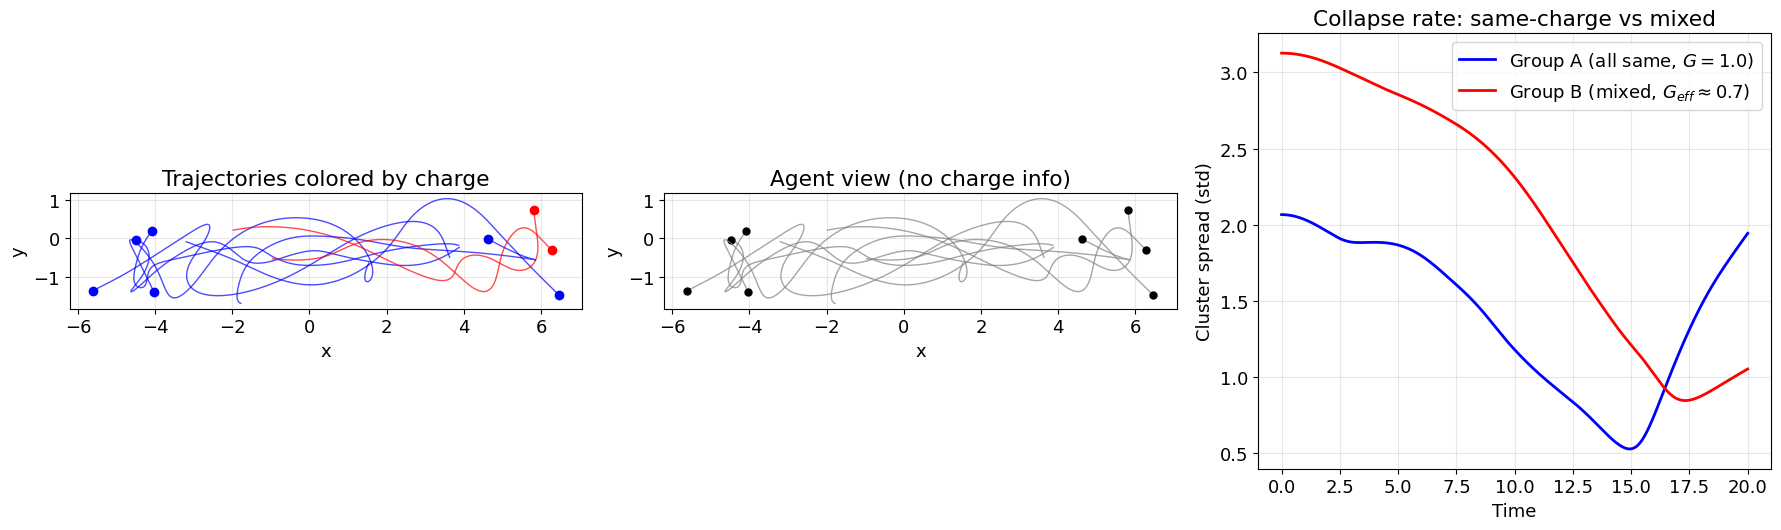

Group A (all same charge): final spread = 1.943
Group B (mixed charges):   final spread = 1.052
Same-charge group collapses faster due to stronger effective attraction.


In [18]:
# --- 2b trajectory: two clear groups to verify the physics ---
# Group A (left): 4 particles, ALL charge +1 → strong same-charge attraction (G_same=1.0)
# Group B (right): 4 particles, MIXED +1/-1 → weaker effective attraction (G_opp=0.3 for mixed pairs)
# Both groups start as loose clusters. Group A should collapse faster.

n_2b = 8
charges_2b = np.array([+1, +1, +1, +1,  # Group A: all same
                        +1, -1, +1, -1], dtype=np.float64)  # Group B: alternating
abs_charges_2b = np.abs(charges_2b)
masses_2b = np.ones(n_2b)

# Group A centered at (-5, 0), Group B centered at (+5, 0)
rng_2b = np.random.RandomState(99)
pos_2b_init = np.vstack([
    np.array([-5, 0]) + rng_2b.uniform(-1.5, 1.5, size=(4, 2)),
    np.array([+5, 0]) + rng_2b.uniform(-1.5, 1.5, size=(4, 2)),
])
vel_2b = np.zeros((n_2b, 2))

n_steps_2b = 4000
pos_2b = (pos_2b_init + center_ch).copy()
vel_2b_run = vel_2b.copy()
traj_2b = np.zeros((n_steps_2b + 1, n_2b, 2))
traj_2b[0] = pos_2b - center_ch

for step in range(n_steps_2b):
    sim_g = FieldSampler(
        particle_inertia=masses_2b, particle_source=abs_charges_2b,
        particle_force=abs_charges_2b,
        initial_positions=pos_2b.copy(), initial_velocities=vel_2b_run.copy(),
        spatial_dimensions=2, temporal_order=0,
        grid_size=(grid_ch, grid_ch), domain_size=domain_ch,
        operators=ops_ch, n_particles=n_2b, force_law='gradient', dt=dt_ch,
        source_coupling=abs_charges_2b, force_coupling=G_grav,
        periodic_boundaries=False,
    )
    sim_e = FieldSampler(
        particle_inertia=masses_2b, particle_source=charges_2b,
        particle_force=charges_2b,
        initial_positions=pos_2b.copy(), initial_velocities=vel_2b_run.copy(),
        spatial_dimensions=2, temporal_order=0,
        grid_size=(grid_ch, grid_ch), domain_size=domain_ch,
        operators=ops_ch, n_particles=n_2b, force_law='gradient', dt=dt_ch,
        source_coupling=charges_2b, force_coupling=G_elec,
        periodic_boundaries=False,
    )

    f_g = np.array(sim_g.step())
    f_e = np.array(sim_e.step())
    f_total = f_g + f_e

    acc = f_total / masses_2b[:, None]
    vel_2b_run += dt_ch * acc
    pos_2b += dt_ch * vel_2b_run
    traj_2b[step + 1] = pos_2b - center_ch

# Compute cluster spread over time
times_2b = np.arange(n_steps_2b + 1) * dt_ch
spread_A = np.array([np.std(traj_2b[t, :4, :]) for t in range(n_steps_2b + 1)])
spread_B = np.array([np.std(traj_2b[t, 4:, :]) for t in range(n_steps_2b + 1)])

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

ax = axes[0]
for i in range(4):
    ax.plot(traj_2b[:, i, 0], traj_2b[:, i, 1], 'b-', lw=1, alpha=0.7)
    ax.plot(traj_2b[0, i, 0], traj_2b[0, i, 1], 'bo', ms=6)
for i in range(4, 8):
    color = 'blue' if charges_2b[i] > 0 else 'red'
    ax.plot(traj_2b[:, i, 0], traj_2b[:, i, 1], '-', lw=1, alpha=0.7, color=color)
    ax.plot(traj_2b[0, i, 0], traj_2b[0, i, 1], 'o', ms=6, color=color)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Trajectories colored by charge')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)

ax = axes[1]
for i in range(n_2b):
    ax.plot(traj_2b[:, i, 0], traj_2b[:, i, 1], '-', lw=1, alpha=0.7, color='gray')
    ax.plot(traj_2b[0, i, 0], traj_2b[0, i, 1], 'ko', ms=5)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Agent view (no charge info)')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(times_2b, spread_A, 'b-', lw=2, label=f'Group A (all same, $G={G_same}$)')
ax.plot(times_2b, spread_B, 'r-', lw=2, label=f'Group B (mixed, $G_{{eff}} \\approx {(G_same+G_opp)/2:.1f}$)')
ax.set_xlabel('Time'); ax.set_ylabel('Cluster spread (std)')
ax.set_title('Collapse rate: same-charge vs mixed')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Group A (all same charge): final spread = {spread_A[-1]:.3f}")
print(f"Group B (mixed charges):   final spread = {spread_B[-1]:.3f}")
print("Same-charge group collapses faster due to stronger effective attraction.")

## Experiment 3 — Dark / invisible particles

Standard 2D Poisson gravity ($\nabla^2\phi = \rho$), but some particles are **invisible**.
They source the field and feel forces, but their trajectories are hidden from the observer.

Setup: two very massive dark particles sit (nearly) stationary.  Light visible particles
stream past and get deflected — sucked toward the invisible masses.  From the agent's
perspective, visible particles curve for no apparent reason.

In [19]:
# --- Setup: light visible particles streaming past massive stationary dark particles ---
n_visible = 6
n_dark = 2
n_total_dark = n_visible + n_dark
domain_dk = 50.0
center_dk = domain_dk / 2
grid_dk = 128
dt_dk = 0.005

m_visible = 1.0
m_dark = 200.0  # very heavy → nearly stationary

# Dark particles: two massive objects placed at fixed positions
dark_positions = np.array([[-4.0, 0.0],   # left dark mass
                            [5.0, 3.0]])   # right dark mass

# Visible particles: start on the left, moving rightward at various y-offsets
# so they pass near the dark masses and get deflected
vis_positions = np.array([
    [-12.0, -3.0],
    [-12.0, -1.0],
    [-12.0,  0.5],
    [-12.0,  2.0],
    [-12.0,  4.0],
    [-12.0,  6.0],
])
vis_velocities = np.array([
    [0.8, 0.0],
    [0.8, 0.0],
    [0.8, 0.0],
    [0.8, 0.0],
    [0.8, 0.0],
    [0.8, 0.0],
])

pos_dk = np.vstack([vis_positions, dark_positions])
vel_dk = np.vstack([vis_velocities, np.zeros((n_dark, 2))])
masses_dk = np.concatenate([np.full(n_visible, m_visible),
                             np.full(n_dark, m_dark)])

ops_dk = [{'type': 'laplacian', 'params': {'strength': 1.0}}]

n_steps_dk = 8000
sim_dk = FieldSampler(
    particle_inertia=masses_dk, particle_source=masses_dk,
    particle_force=masses_dk,
    initial_positions=(pos_dk + center_dk).copy(),
    initial_velocities=vel_dk.copy(),
    spatial_dimensions=2, temporal_order=0,
    grid_size=(grid_dk, grid_dk), domain_size=domain_dk,
    operators=ops_dk, n_particles=n_total_dark,
    force_law='gradient', dt=dt_dk,
    source_coupling=masses_dk, force_coupling=1.0,
    periodic_boundaries=False,
    source_smoothing=max(domain_dk / grid_dk, 0.5),
)

traj_dk = np.zeros((n_steps_dk + 1, n_total_dark, 2))
vel_dk_hist = np.zeros((n_steps_dk + 1, n_total_dark, 2))
traj_dk[0] = sim_dk.positions - center_dk
vel_dk_hist[0] = sim_dk.velocities.copy()

for step in range(n_steps_dk):
    sim_dk.step()
    traj_dk[step + 1] = sim_dk.positions - center_dk
    vel_dk_hist[step + 1] = sim_dk.velocities.copy()

print(f"Simulation: {n_visible} visible (m={m_visible}) + {n_dark} dark (m={m_dark})")
print(f"Dark particles at: {dark_positions.tolist()}")
print(f"Visible particles start at x=-12, streaming rightward at v=0.8")

Simulation: 6 visible (m=1.0) + 2 dark (m=200.0)
Dark particles at: [[-4.0, 0.0], [5.0, 3.0]]
Visible particles start at x=-12, streaming rightward at v=0.8


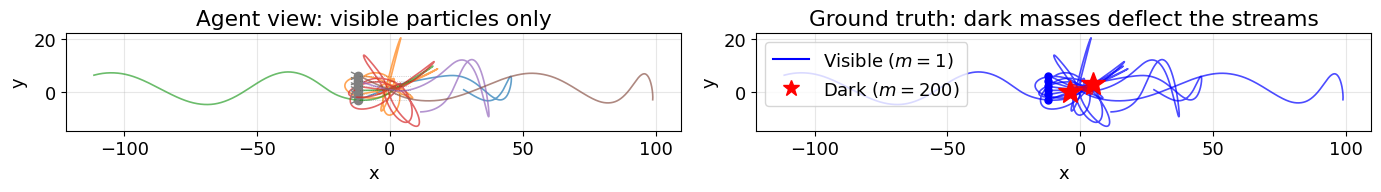

Left panel: agent sees particles curving for no reason.
Right panel: massive invisible particles are bending the trajectories.


In [22]:
# --- Trajectory plots: visible-only vs all particles ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
for i in range(n_visible):
    ax.plot(traj_dk[:, i, 0], traj_dk[:, i, 1], '-', lw=1.2, alpha=0.7)
    ax.plot(traj_dk[0, i, 0], traj_dk[0, i, 1], 'o', ms=6, color='gray')
    ax.annotate('', xy=traj_dk[0, i] + [0.8, 0], xytext=traj_dk[0, i],
                arrowprops=dict(arrowstyle='->', color='gray', lw=1))
# Show straight-line reference (no dark matter)
for i in range(n_visible):
    x0 = traj_dk[0, i, 0]
    y0 = traj_dk[0, i, 1]
    ax.plot([x0, x0 + 20], [y0, y0], 'k:', lw=0.5, alpha=0.3)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Agent view: visible particles only')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)

ax = axes[1]
for i in range(n_visible):
    ax.plot(traj_dk[:, i, 0], traj_dk[:, i, 1], 'b-', lw=1.2, alpha=0.7)
    ax.plot(traj_dk[0, i, 0], traj_dk[0, i, 1], 'bo', ms=5)
for i in range(n_visible, n_total_dark):
    ax.plot(traj_dk[:, i, 0], traj_dk[:, i, 1], 'r-', lw=1.5, alpha=0.5)
    ax.plot(traj_dk[0, i, 0], traj_dk[0, i, 1], 'r*', ms=18, zorder=10)
ax.plot([], [], 'b-', label='Visible ($m=1$)')
ax.plot([], [], 'r*', ms=12, label=f'Dark ($m={int(m_dark)}$)')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Ground truth: dark masses deflect the streams')
ax.set_aspect('equal'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Left panel: agent sees particles curving for no reason.")
print("Right panel: massive invisible particles are bending the trajectories.")

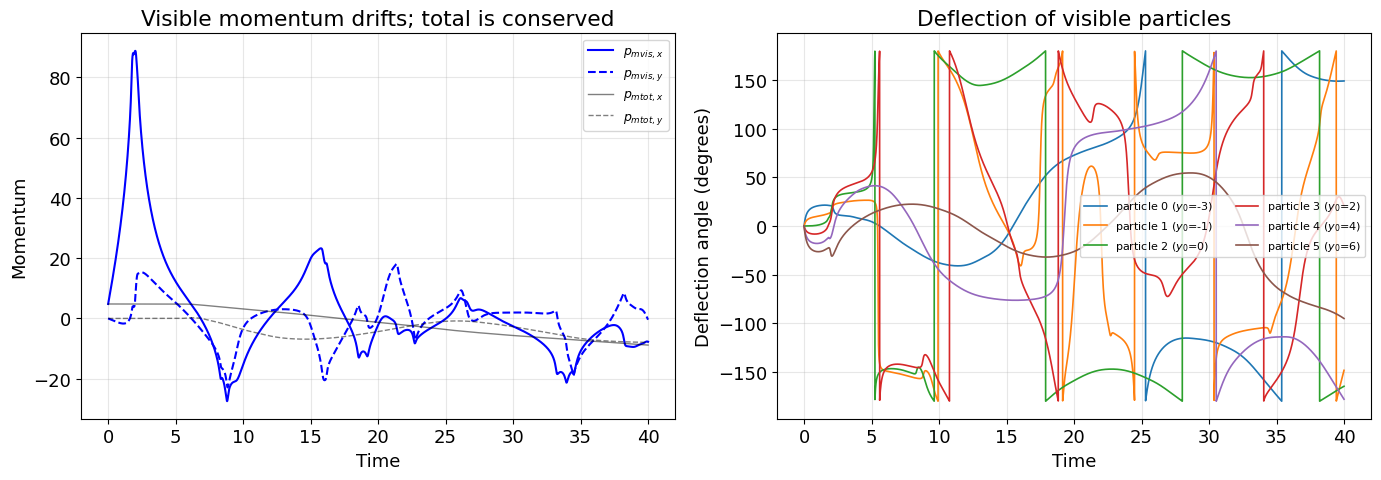

Particles that pass closer to a dark mass get deflected more.


In [24]:
# --- Momentum and deflection analysis ---
times_dk = np.arange(n_steps_dk + 1) * dt_dk

# Visible momentum
p_visible = np.zeros((n_steps_dk + 1, 2))
for i in range(n_visible):
    p_visible += masses_dk[i] * vel_dk_hist[:, i, :]

# Total momentum (should be conserved)
p_total = np.zeros((n_steps_dk + 1, 2))
for i in range(n_total_dark):
    p_total += masses_dk[i] * vel_dk_hist[:, i, :]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(times_dk, p_visible[:, 0], 'b-', lw=1.5, label='$p_{m vis,x}$')
ax.plot(times_dk, p_visible[:, 1], 'b--', lw=1.5, label='$p_{m vis,y}$')
ax.plot(times_dk, p_total[:, 0], 'k-', lw=1, alpha=0.5, label='$p_{m tot,x}$')
ax.plot(times_dk, p_total[:, 1], 'k--', lw=1, alpha=0.5, label='$p_{m tot,y}$')
ax.set_xlabel('Time')
ax.set_ylabel('Momentum')
ax.set_title('Visible momentum drifts; total is conserved')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
for i in range(n_visible):
    v_init = vel_dk_hist[0, i]
    angle_init = np.arctan2(v_init[1], v_init[0])
    angles_t = np.arctan2(vel_dk_hist[:, i, 1], vel_dk_hist[:, i, 0])
    deflection = np.degrees(angles_t - angle_init)
    ax.plot(times_dk, deflection, '-', lw=1.2,
            label=f'particle {i} ($y_0$={vis_positions[i,1]:.0f})')
ax.set_xlabel('Time')
ax.set_ylabel('Deflection angle (degrees)')
ax.set_title('Deflection of visible particles')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Particles that pass closer to a dark mass get deflected more.")

KeyboardInterrupt: 

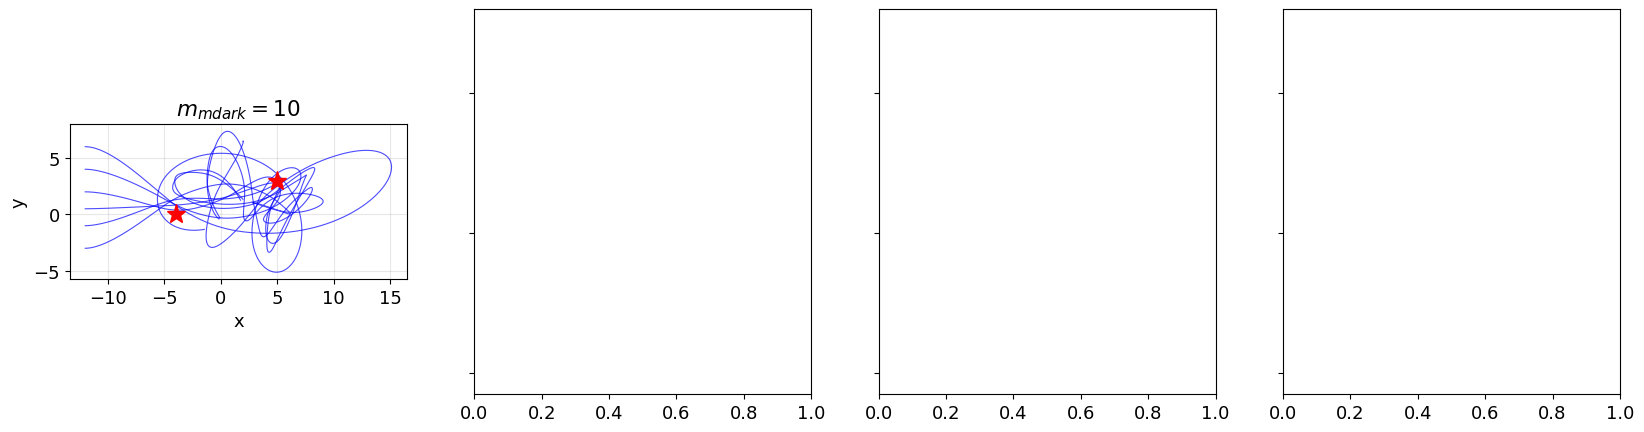

In [26]:
# --- Vary dark mass: effect on deflection ---
dark_masses_test = [10, 50, 200, 500]
fig, axes = plt.subplots(1, len(dark_masses_test), figsize=(5 * len(dark_masses_test), 5),
                          sharey=True)

for ax_idx, m_dk_test in enumerate(dark_masses_test):
    masses_test = np.concatenate([np.full(n_visible, m_visible),
                                   np.full(n_dark, m_dk_test)])
    sim_test = FieldSampler(
        particle_inertia=masses_test, particle_source=masses_test,
        particle_force=masses_test,
        initial_positions=(pos_dk + center_dk).copy(),
        initial_velocities=vel_dk.copy(),
        spatial_dimensions=2, temporal_order=0,
        grid_size=(grid_dk, grid_dk), domain_size=domain_dk,
        operators=ops_dk, n_particles=n_total_dark,
        force_law='gradient', dt=dt_dk,
        source_coupling=masses_test, force_coupling=1.0,
        periodic_boundaries=False,
        source_smoothing=max(domain_dk / grid_dk, 0.5),
    )
    traj_test = np.zeros((n_steps_dk + 1, n_total_dark, 2))
    traj_test[0] = sim_test.positions - center_dk
    for step in range(n_steps_dk):
        sim_test.step()
        traj_test[step + 1] = sim_test.positions - center_dk

    ax = axes[ax_idx]
    for i in range(n_visible):
        ax.plot(traj_test[:, i, 0], traj_test[:, i, 1], 'b-', lw=0.8, alpha=0.7)
    for i in range(n_visible, n_total_dark):
        ax.plot(traj_test[0, i, 0], traj_test[0, i, 1], 'r*', ms=14)
    ax.set_xlabel('x')
    if ax_idx == 0:
        ax.set_ylabel('y')
    ax.set_title(f'$m_{{m dark}} = {m_dk_test}$')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.suptitle('Effect of dark mass on visible particle deflection', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
print("Heavier dark particles → stronger deflection of visible streams.")

## Experiment 4 — Running coupling (asymptotic freedom)

$$F = \frac{g(r)\, m_i\, m_j}{r^2}, \qquad g(r) = \frac{g_0}{1 + g_0 \ln(r/r_0)}$$

The effective coupling constant **runs** with distance:
- At short range ($r \ll r_0$): $g(r)$ grows (strong coupling)
- At long range ($r \gg r_0$): $g(r) \to 0$ logarithmically (asymptotic freedom)

**Stability note**: The effective exponent $d(\ln F)/d(\ln r)$ steepens at small $r$.
When it exceeds $-3$, circular orbits become **unstable** (Bertrand's theorem).
The critical radius is $r_{\rm crit} = r_0\, e^{1 - 1/g_0}$. All orbits must start above this.

This mimics QCD-like running. No linear PDE can produce a scale-dependent coupling.
Fitting a naive $F \propto 1/r^n$ over different distance windows yields different effective exponents.

Parameters: g0=0.5, r0=5.0
Critical radius (orbits unstable below this): r_crit = 1.84



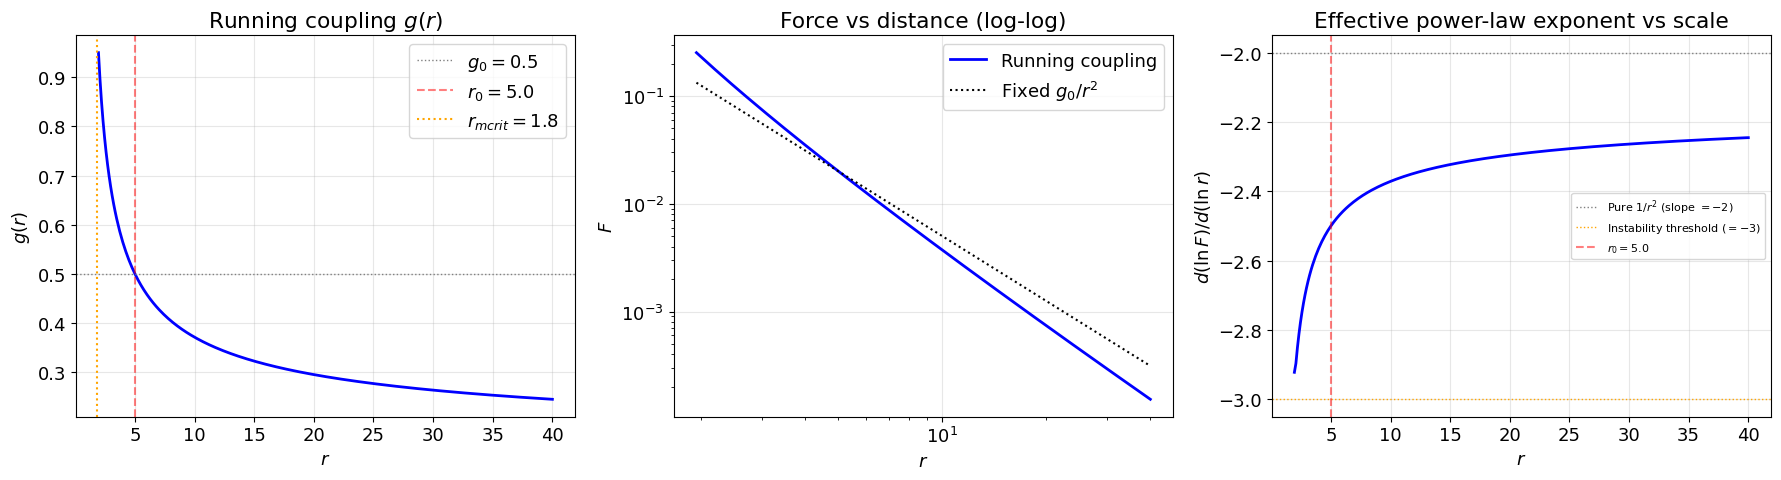

  r =   2.5: g(r) = 0.778, eff. exponent = -2.78
  r =   5.0: g(r) = 0.500, eff. exponent = -2.50
  r =  15.0: g(r) = 0.322, eff. exponent = -2.32
  r =  30.0: g(r) = 0.264, eff. exponent = -2.26


In [32]:
g0 = 0.5
r0 = 5.0
eps_run = 0.05

def running_coupling_force(r_vec, r_mag, m_i, m_j, label_i, label_j):
    """F = g(r) * m_i * m_j / r^2, with g(r) = g0 / (1 + g0 * ln(r/r0))."""
    r_safe = max(r_mag, 1e-6)
    g = g0 / (1.0 + g0 * np.log(r_safe / r0))
    F_mag = g * m_i * m_j / (r_mag**2 + eps_run**2)
    return -F_mag * r_vec / r_mag

# Critical radius: orbits with r < r_crit are unstable because the effective
# force law is steeper than 1/r^3 (from the running making g(r) blow up).
r_crit = r0 * np.exp(1 - 1 / g0)
print(f"Parameters: g0={g0}, r0={r0}")
print(f"Critical radius (orbits unstable below this): r_crit = {r_crit:.2f}")
print()

# --- Force vs distance ---
r_run = np.linspace(max(r_crit + 0.1, 0.5), 40.0, 300)
g_of_r = g0 / (1.0 + g0 * np.log(r_run / r0))
F_run = g_of_r / r_run**2
F_fixed = g0 / r_run**2

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(r_run, g_of_r, 'b-', lw=2)
ax.axhline(g0, color='gray', ls=':', lw=1, label=f'$g_0 = {g0}$')
ax.axvline(r0, color='r', ls='--', lw=1.5, alpha=0.5, label=f'$r_0 = {r0}$')
ax.axvline(r_crit, color='orange', ls=':', lw=1.5, label=f'$r_{{m crit}} = {r_crit:.1f}$')
ax.set_xlabel('$r$'); ax.set_ylabel('$g(r)$')
ax.set_title('Running coupling $g(r)$')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(r_run, F_run, 'b-', lw=2, label='Running coupling')
ax.plot(r_run, F_fixed, 'k:', lw=1.5, label='Fixed $g_0/r^2$')
ax.set_xlabel('$r$'); ax.set_ylabel('$F$')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_title('Force vs distance (log-log)')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[2]
log_r = np.log(r_run)
log_F = np.log(np.maximum(F_run, 1e-30))
d_logF_d_logr = np.gradient(log_F, log_r)
ax.plot(r_run, d_logF_d_logr, 'b-', lw=2)
ax.axhline(-2, color='gray', ls=':', lw=1, label='Pure $1/r^2$ (slope $= -2$)')
ax.axhline(-3, color='orange', ls=':', lw=1, label='Instability threshold ($= -3$)')
ax.axvline(r0, color='r', ls='--', lw=1.5, alpha=0.5, label=f'$r_0 = {r0}$')
ax.set_xlabel('$r$'); ax.set_ylabel('$d(\\ln F) / d(\\ln r)$')
ax.set_title('Effective power-law exponent vs scale')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for r_test in [2.5, 5.0, 15.0, 30.0]:
    idx = np.argmin(np.abs(r_run - r_test))
    print(f"  r = {r_test:5.1f}: g(r) = {g_of_r[idx]:.3f}, eff. exponent = {d_logF_d_logr[idx]:.2f}")

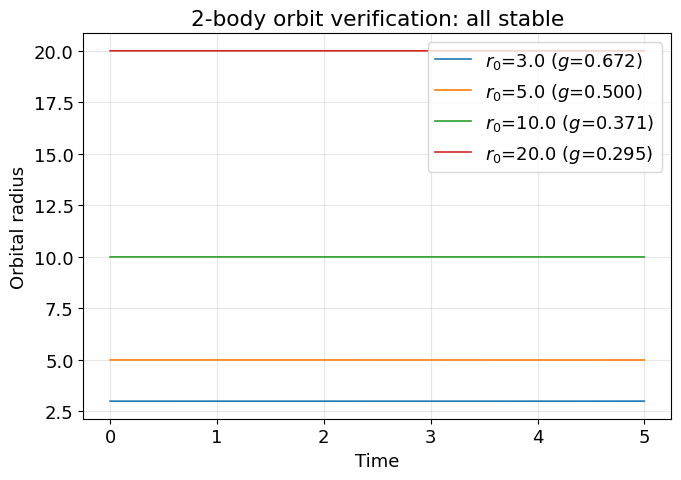

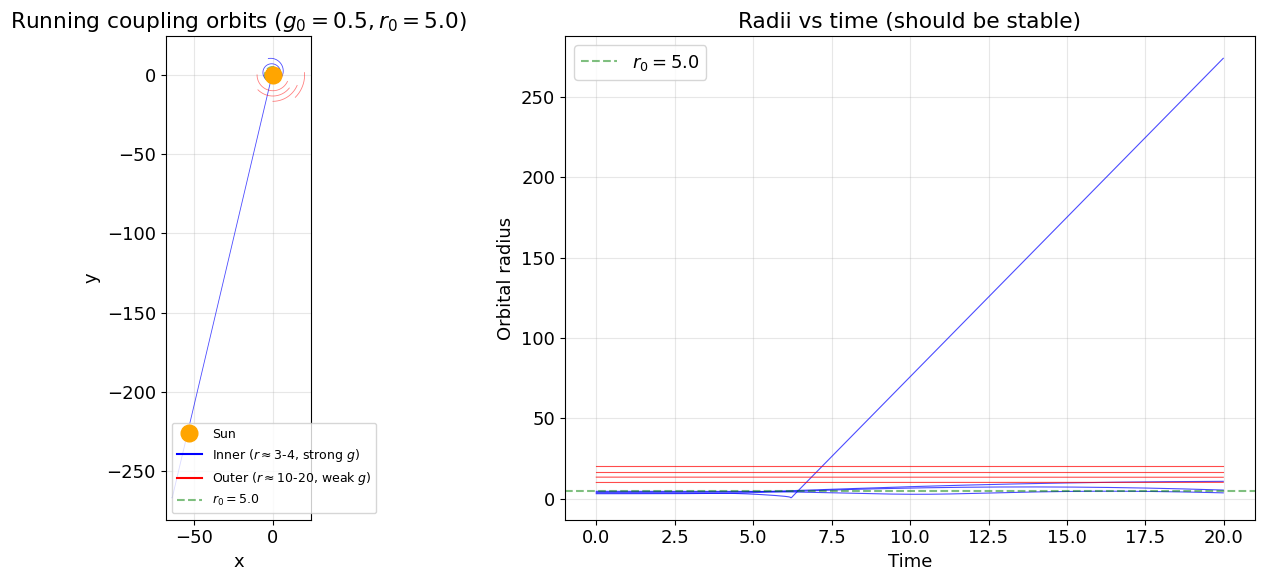


Orbit stability:
  Planet 0 (inner, r=3.0, g=0.672): drift = 75.784%
  Planet 1 (inner, r=3.5, g=0.609): drift = 7735.605%
  Planet 2 (inner, r=4.0, g=0.563): drift = 167.815%
  Planet 3 (inner, r=4.5, g=0.528): drift = 21.375%
  Planet 4 (outer, r=10.0, g=0.371): drift = 0.728%
  Planet 5 (outer, r=13.3, g=0.335): drift = 0.607%
  Planet 6 (outer, r=16.7, g=0.312): drift = 0.001%
  Planet 7 (outer, r=20.0, g=0.295): drift = 0.013%


In [30]:
# --- Verification: 2-body orbit test ---
M_sun_run = 50.0
m_planet_run = 0.01  # test mass (negligible back-reaction on sun)
dt_run = 0.001

test_radii = [3.0, 5.0, 10.0, 20.0]
fig_v, ax_v = plt.subplots(1, 1, figsize=(7, 5))

for r_test in test_radii:
    g_r = g0 / (1.0 + g0 * np.log(r_test / r0))
    F_r = g_r * M_sun_run * m_planet_run / r_test**2
    v_c = np.sqrt(F_r * r_test / m_planet_run)

    pos_t = np.array([[0.0, 0.0], [r_test, 0.0]])
    vel_t = np.array([[0.0, 0.0], [0.0, v_c]])
    masses_t = np.array([M_sun_run, m_planet_run])
    n_orb_steps = 5000
    radii_t = np.zeros(n_orb_steps)
    for step in range(n_orb_steps):
        rv = pos_t[0] - pos_t[1]
        rm = np.linalg.norm(rv)
        f = running_coupling_force(rv, rm, masses_t[0], masses_t[1], 1.0, 1.0)
        vel_t[0] += dt_run * f / masses_t[0]
        vel_t[1] -= dt_run * f / masses_t[1]
        pos_t += dt_run * vel_t
        radii_t[step] = np.linalg.norm(pos_t[1] - pos_t[0])

    times_t = np.arange(n_orb_steps) * dt_run
    ax_v.plot(times_t, radii_t, lw=1.2, label=f'$r_0$={r_test} ($g$={g_r:.3f})')

ax_v.set_xlabel('Time'); ax_v.set_ylabel('Orbital radius')
ax_v.set_title('2-body orbit verification: all stable')
ax_v.legend(); ax_v.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Multi-planet system ---
n_inner = 4
n_outer = 4
radii_inner = np.linspace(3.0, 4.5, n_inner)
radii_outer = np.linspace(10.0, 20.0, n_outer)
all_radii_run = np.concatenate([radii_inner, radii_outer])
n_p_run = len(all_radii_run)
angles_run = np.linspace(0, 2 * np.pi, n_p_run, endpoint=False)
n_steps_run = 20000

positions_run = np.zeros((1 + n_p_run, 2))
velocities_run = np.zeros((1 + n_p_run, 2))
masses_run = np.concatenate([[M_sun_run], np.full(n_p_run, m_planet_run)])

for idx in range(n_p_run):
    r = all_radii_run[idx]
    positions_run[1 + idx] = [r * np.cos(angles_run[idx]),
                               r * np.sin(angles_run[idx])]
    g_r = g0 / (1.0 + g0 * np.log(max(r, 1e-6) / r0))
    F_r = g_r * M_sun_run * m_planet_run / r**2
    v_circ = np.sqrt(F_r * r / m_planet_run)
    velocities_run[1 + idx] = v_circ * np.array([-np.sin(angles_run[idx]),
                                                   np.cos(angles_run[idx])])

result_run = nbody_simulate(
    positions_run, velocities_run, masses_run, running_coupling_force,
    dt=dt_run, n_steps=n_steps_run,
    measurement_times=[0.0] + list(np.arange(dt_run, n_steps_run * dt_run, dt_run * 20)),
)

traj_run = np.array(result_run['positions'])
times_run = np.array(result_run['measurement_times'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.plot(0, 0, 'o', ms=12, color='orange', zorder=10, label='Sun')
for idx in range(n_inner):
    t = traj_run[1 + idx]
    ax.plot(t[:, 0], t[:, 1], 'b-', lw=0.6, alpha=0.7)
for idx in range(n_inner, n_p_run):
    t = traj_run[1 + idx]
    ax.plot(t[:, 0], t[:, 1], 'r-', lw=0.6, alpha=0.5)
ax.plot([], [], 'b-', label=f'Inner ($r \\approx {radii_inner[0]:.0f}$-${radii_inner[-1]:.0f}$, strong $g$)')
ax.plot([], [], 'r-', label=f'Outer ($r \\approx {radii_outer[0]:.0f}$-${radii_outer[-1]:.0f}$, weak $g$)')
theta_c = np.linspace(0, 2 * np.pi, 100)
ax.plot(r0 * np.cos(theta_c), r0 * np.sin(theta_c), 'g--', lw=1.5, alpha=0.5,
        label=f'$r_0 = {r0}$')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title(f'Running coupling orbits ($g_0={g0}, r_0={r0}$)')
ax.set_aspect('equal'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
for idx in range(n_p_run):
    t = traj_run[1 + idx]
    r_t = np.linalg.norm(t, axis=1)
    color = 'blue' if idx < n_inner else 'red'
    ax.plot(times_run[:len(r_t)], r_t, '-', lw=0.8, color=color, alpha=0.7)
ax.axhline(r0, color='g', ls='--', lw=1.5, alpha=0.5, label=f'$r_0={r0}$')
ax.set_xlabel('Time'); ax.set_ylabel('Orbital radius')
ax.set_title('Radii vs time (should be stable)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nOrbit stability:")
for idx in range(n_p_run):
    t = traj_run[1 + idx]
    r_arr = np.linalg.norm(t, axis=1)
    r_init = all_radii_run[idx]
    drift = abs(r_arr[-1] - r_init) / r_init
    label = "inner" if idx < n_inner else "outer"
    g_val = g0 / (1 + g0 * np.log(r_init / r0))
    print(f"  Planet {idx} ({label}, r={r_init:.1f}, g={g_val:.3f}): drift = {drift:.3%}")

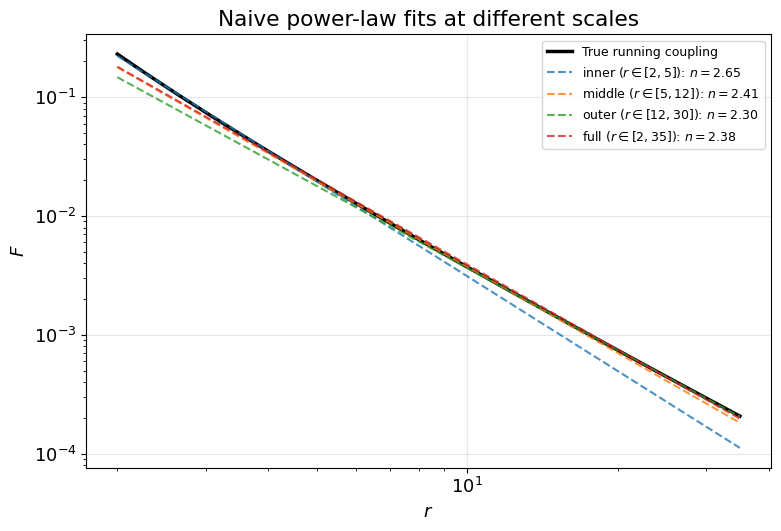

The 'discovered exponent' depends on which distance window you probe.


In [33]:
# --- Fit naive 1/r^n at different scale windows ---
r_fit = np.linspace(2.0, 35.0, 200)
F_fit_true = (g0 / (1.0 + g0 * np.log(r_fit / r0))) / r_fit**2

windows_run = [
    (2.0, 5.0, 'inner'),
    (5.0, 12.0, 'middle'),
    (12.0, 30.0, 'outer'),
    (2.0, 35.0, 'full'),
]

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(r_fit, F_fit_true, 'k-', lw=2.5, label='True running coupling')

for r_min, r_max, label in windows_run:
    mask = (r_fit >= r_min) & (r_fit <= r_max)
    lr = np.log(r_fit[mask])
    lf = np.log(np.maximum(F_fit_true[mask], 1e-30))
    slope, intercept = np.polyfit(lr, lf, 1)
    F_pw = np.exp(intercept) * r_fit**slope
    ax.plot(r_fit, F_pw, '--', lw=1.5, alpha=0.8,
            label=f'{label} ($r \\in [{r_min:.0f},{r_max:.0f}]$): $n = {-slope:.2f}$')

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('$r$'); ax.set_ylabel('$F$')
ax.set_title('Naive power-law fits at different scales')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("The 'discovered exponent' depends on which distance window you probe.")

## Experiment 5 — 2D screened Poisson (Yukawa)

$$(\nabla^2 - 1/\lambda^2)\,\phi = \rho$$

The 2D Green's function is $K_0(r/\lambda)$ (modified Bessel).  The force is
$F \sim K_1(r/\lambda)/\lambda$, which behaves like $\sim 1/r$ at short range
(standard 2D gravity) and like $\sim e^{-r/\lambda}/\!\sqrt{r/\lambda}$ at long range.

This is a natural comparison with experiment 1: both feature exponential screening,
but with different prefactors at large $r$:
- Experiment 1: $F \sim e^{-r/\lambda}/r^2$
- Experiment 5: $F \sim e^{-r/\lambda}/\!\sqrt{r}$

This also validates that FieldSampler's `screening` operator works correctly.

NameError: name 'G_scr' is not defined

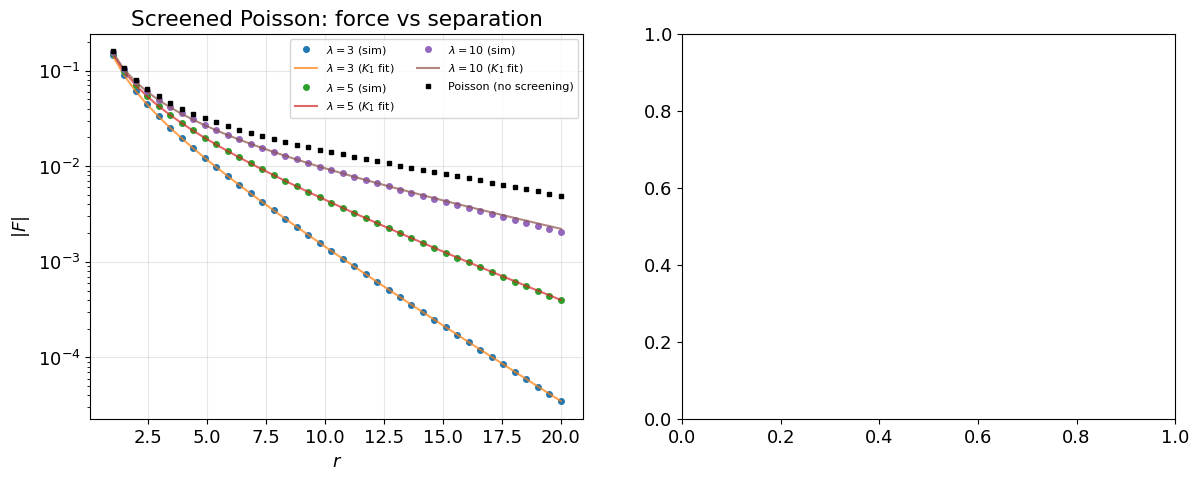

In [ ]:
# --- Force vs separation for the screening operator ---
domain_yk = 60.0
center_yk = domain_yk / 2
grid_yk = 256
dt_yk = 0.005

def measure_screening_force(lam, separations, m1=1.0, m2=1.0):
    """Measure radial force from FieldSampler screening operator at various separations."""
    ops = [{'type': 'screening', 'params': {'strength': 1.0, 'screening_length': lam}}]
    forces = []
    for sep in separations:
        p = np.array([[center_yk - sep / 2, center_yk],
                       [center_yk + sep / 2, center_yk]])
        v = np.zeros((2, 2))
        ms = np.array([m1, m2])
        sim = FieldSampler(
            particle_inertia=ms, particle_source=ms, particle_force=ms,
            initial_positions=p.copy(), initial_velocities=v.copy(),
            spatial_dimensions=2, temporal_order=0,
            grid_size=(grid_yk, grid_yk), domain_size=domain_yk,
            operators=ops, n_particles=2, force_law='gradient', dt=dt_yk,
            source_coupling=ms, force_coupling=1.0, periodic_boundaries=False,
            source_smoothing=max(domain_yk / grid_yk, 0.3),
        )
        f = sim.step()
        r_hat = np.array([1.0, 0.0])
        forces.append(float(jnp.dot(f[0], r_hat)))
    return np.array(forces)

# Also measure pure Poisson for comparison
def measure_poisson_force(separations, m1=1.0, m2=1.0):
    ops = [{'type': 'laplacian', 'params': {'strength': 1.0}}]
    forces = []
    for sep in separations:
        p = np.array([[center_yk - sep / 2, center_yk],
                       [center_yk + sep / 2, center_yk]])
        v = np.zeros((2, 2))
        ms = np.array([m1, m2])
        sim = FieldSampler(
            particle_inertia=ms, particle_source=ms, particle_force=ms,
            initial_positions=p.copy(), initial_velocities=v.copy(),
            spatial_dimensions=2, temporal_order=0,
            grid_size=(grid_yk, grid_yk), domain_size=domain_yk,
            operators=ops, n_particles=2, force_law='gradient', dt=dt_yk,
            source_coupling=ms, force_coupling=1.0, periodic_boundaries=False,
            source_smoothing=max(domain_yk / grid_yk, 0.3),
        )
        f = sim.step()
        r_hat = np.array([1.0, 0.0])
        forces.append(float(jnp.dot(f[0], r_hat)))
    return np.array(forces)

seps_yk = np.linspace(1.0, 20.0, 40)
F_poisson = measure_poisson_force(seps_yk)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for lam in [3, 5, 10]:
    F_yk = measure_screening_force(lam, seps_yk)
    # Analytic: F ~ m1*m2 * K_1(r/lam) / (2*pi*lam)  (up to normalization)
    K1_theory = besselk(1, seps_yk / lam)
    # Fit normalization from data
    norm = np.median(np.abs(F_yk) / K1_theory)
    axes[0].plot(seps_yk, np.abs(F_yk), 'o', ms=4, label=f'$\\lambda={lam}$ (sim)')
    axes[0].plot(seps_yk, norm * K1_theory, '-', lw=1.5, alpha=0.7,
                 label=f'$\\lambda={lam}$ ($K_1$ fit)')

axes[0].plot(seps_yk, np.abs(F_poisson), 'ks', ms=3, label='Poisson (no screening)')
axes[0].set_xlabel('$r$'); axes[0].set_ylabel('$|F|$')
axes[0].set_yscale('log')
axes[0].set_title('Screened Poisson: force vs separation')
axes[0].legend(fontsize=8, ncol=2)
axes[0].grid(True, alpha=0.3)

# Side-by-side with experiment 1
lam_compare = 5.0
F_yk_5 = measure_screening_force(lam_compare, seps_yk)
F_exp1 = G_scr / seps_yk**2 * np.exp(-seps_yk / lam_compare)

# Normalize both to 1 at r = 1
F_yk_norm = np.abs(F_yk_5) / np.abs(F_yk_5[0])
F_exp1_norm = F_exp1 / F_exp1[0]

axes[1].plot(seps_yk, F_yk_norm, 'b-', lw=2, label='Exp 5: 2D Yukawa ($K_1$)')
axes[1].plot(seps_yk, F_exp1_norm, 'r-', lw=2, label='Exp 1: $1/r^2 \\cdot e^{-r/\\lambda}$')
axes[1].set_xlabel('$r$'); axes[1].set_ylabel('$F / F(r_0)$ (normalized)')
axes[1].set_yscale('log')
axes[1].set_title(f'Comparison at $\\lambda = {lam_compare}$')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Both have exponential screening, but different power-law prefactors.")

In [ ]:
# --- Yukawa solar system orbits ---
lam_yk_orb = 5.0
M_sun_yk = 100.0
m_planet_yk = 0.01
n_planets_yk = 50
dt_yk_orb = 0.002
grid_yk_orb = 256
smooth_yk = max(domain_yk / grid_yk_orb, 0.5)

ops_yk_orb = [{'type': 'screening', 'params': {'strength': 1.0,
                                                 'screening_length': lam_yk_orb}}]

rng_yk = np.random.RandomState(7)
sun_pos_yk = np.array([[center_yk, center_yk]])
radii_yk = np.linspace(1.5, 18.0, n_planets_yk)
angles_yk = rng_yk.uniform(0, 2 * np.pi, n_planets_yk)
planet_pos_yk = np.stack([center_yk + radii_yk * np.cos(angles_yk),
                           center_yk + radii_yk * np.sin(angles_yk)], axis=1)
positions_yk = np.vstack([sun_pos_yk, planet_pos_yk])
masses_yk = np.concatenate([[M_sun_yk], np.full(n_planets_yk, m_planet_yk)])

# Calibrate circular velocities from simulation force
sim_yk_cal = FieldSampler(
    particle_inertia=masses_yk, particle_source=masses_yk, particle_force=masses_yk,
    initial_positions=positions_yk.copy(),
    initial_velocities=np.zeros((1 + n_planets_yk, 2)),
    spatial_dimensions=2, temporal_order=0,
    grid_size=(grid_yk_orb, grid_yk_orb), domain_size=domain_yk,
    operators=ops_yk_orb, n_particles=1 + n_planets_yk, force_law='gradient',
    dt=dt_yk_orb, source_coupling=masses_yk, force_coupling=1.0,
    periodic_boundaries=False, source_smoothing=smooth_yk,
)
forces_yk_cal = sim_yk_cal.step()

velocities_yk = np.zeros((1 + n_planets_yk, 2))
v_circs_yk = []
for idx in range(n_planets_yk):
    i = 1 + idx
    disp = sim_yk_cal.positions[i] - center_yk
    r = np.linalg.norm(disp)
    rhat = disp / r
    f_rad = abs(float(jnp.dot(forces_yk_cal[i], rhat)))
    v = np.sqrt(f_rad * r / m_planet_yk)
    v_circs_yk.append(v)
    tangent = np.array([-np.sin(angles_yk[idx]), np.cos(angles_yk[idx])])
    velocities_yk[1 + idx] = v * tangent

# Evolve
n_steps_yk = 6000
sim_yk_run = FieldSampler(
    particle_inertia=masses_yk, particle_source=masses_yk, particle_force=masses_yk,
    initial_positions=positions_yk.copy(), initial_velocities=velocities_yk.copy(),
    spatial_dimensions=2, temporal_order=0,
    grid_size=(grid_yk_orb, grid_yk_orb), domain_size=domain_yk,
    operators=ops_yk_orb, n_particles=1 + n_planets_yk, force_law='gradient',
    dt=dt_yk_orb, source_coupling=masses_yk, force_coupling=1.0,
    periodic_boundaries=False, source_smoothing=smooth_yk,
)

traj_yk = np.zeros((n_steps_yk + 1, 1 + n_planets_yk, 2))
traj_yk[0] = sim_yk_run.positions.copy()
for step in range(n_steps_yk):
    sim_yk_run.step()
    traj_yk[step + 1] = sim_yk_run.positions.copy()

traj_yk_c = traj_yk - center_yk

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
colors_yk = plt.cm.viridis(np.linspace(0, 1, n_planets_yk))

ax = axes[0]
ax.plot(0, 0, 'o', ms=12, color='orange', zorder=10)
for idx in range(n_planets_yk):
    i = 1 + idx
    ax.plot(traj_yk_c[:, i, 0], traj_yk_c[:, i, 1], '-', lw=0.3, alpha=0.5,
            color=colors_yk[idx])
theta_c = np.linspace(0, 2 * np.pi, 100)
ax.plot(lam_yk_orb * np.cos(theta_c), lam_yk_orb * np.sin(theta_c),
        'r--', lw=2, alpha=0.5, label=f'$\\lambda={lam_yk_orb}$')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title(f'Yukawa solar system ($\\lambda={lam_yk_orb}$)')
ax.set_aspect('equal'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
times_yk = np.arange(n_steps_yk + 1) * dt_yk_orb
for idx in range(n_planets_yk):
    i = 1 + idx
    r_t = np.linalg.norm(traj_yk_c[:, i, :], axis=1)
    ax.plot(times_yk, r_t, '-', lw=0.3, alpha=0.5, color=colors_yk[idx])
ax.axhline(lam_yk_orb, color='r', ls='--', lw=1.5, alpha=0.5)
ax.set_xlabel('Time'); ax.set_ylabel('Orbital radius')
ax.set_title('Orbital radii vs time')
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.scatter(radii_yk, v_circs_yk, s=15, alpha=0.7, c=colors_yk, label='Calibrated $v_{circ}$')
ax.axvline(lam_yk_orb, color='r', ls='--', lw=1.5, alpha=0.5, label=f'$\\lambda={lam_yk_orb}$')
ax.set_xlabel('Orbital radius'); ax.set_ylabel('$v_{\\rm circ}$')
ax.set_title('Circular velocity vs radius')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nOrbit stability (screened Poisson, lambda={lam_yk_orb}):")
for idx in [0, n_planets_yk // 4, n_planets_yk // 2, 3 * n_planets_yk // 4, n_planets_yk - 1]:
    i = 1 + idx
    r0 = np.linalg.norm(traj_yk_c[0, i])
    rf = np.linalg.norm(traj_yk_c[-1, i])
    drift = abs(rf - r0) / max(r0, 1e-10)
    label = "inner" if r0 < lam_yk_orb else "outer"
    print(f"  Planet {idx} ({label}): r0={r0:.2f}, rf={rf:.2f}, drift={drift:.1%}")

In [ ]:
# --- Discoverability: how much long-range data is needed? ---
seps_disc = np.linspace(1.0, 18.0, 40)
F_yk_disc = np.abs(measure_screening_force(lam_yk_orb, seps_disc))
F_poisson_disc = np.abs(measure_poisson_force(seps_disc))

windows_yk = [
    (1.0, 3.0, f'$r < \\lambda/2 = {lam_yk_orb/2}$'),
    (1.0, 5.0, f'$r < \\lambda = {lam_yk_orb}$'),
    (1.0, 10.0, f'$r < 2\\lambda$'),
    (1.0, 18.0, 'full range'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(seps_disc, F_yk_disc, 'ko', ms=4, label=f'Yukawa ($\\lambda={lam_yk_orb}$)')
ax.plot(seps_disc, F_poisson_disc, 'gs', ms=3, alpha=0.5, label='Poisson')
for r_min, r_max, label in windows_yk:
    mask = (seps_disc >= r_min) & (seps_disc <= r_max)
    lr = np.log(seps_disc[mask])
    lf = np.log(F_yk_disc[mask])
    slope, intercept = np.polyfit(lr, lf, 1)
    F_pw = np.exp(intercept) * seps_disc**slope
    ax.plot(seps_disc, F_pw, '--', lw=1.5, alpha=0.7,
            label=f'{label}: $n = {-slope:.2f}$')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('$r$'); ax.set_ylabel('$|F|$')
ax.set_title('Power-law fits at different windows (2D Yukawa)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
ratio = F_yk_disc / F_poisson_disc
ax.plot(seps_disc, ratio, 'ko-', lw=2, ms=4)
ax.axhline(1.0, color='gray', ls=':', lw=1)
ax.axvline(lam_yk_orb, color='r', ls='--', lw=1.5, alpha=0.5,
           label=f'$\\lambda = {lam_yk_orb}$')
ax.set_xlabel('$r$')
ax.set_ylabel('$F_{\\rm Yukawa} / F_{\\rm Poisson}$')
ax.set_title('Yukawa / Poisson force ratio')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"At r = lambda = {lam_yk_orb}: Yukawa force is "
      f"{ratio[np.argmin(np.abs(seps_disc - lam_yk_orb))]:.1%} of Poisson")
print(f"At r = 2*lambda = {2*lam_yk_orb}: Yukawa force is "
      f"{ratio[np.argmin(np.abs(seps_disc - 2*lam_yk_orb))]:.1%} of Poisson")

## Summary

### Discoverability comparison

| # | Experiment | Short-range discoverable? | Latent variables? | Multi-scale needed? | Difficulty |
|---|-----------|--------------------------|-------------------|---------------------|------------|
| 1 | Screened $1/r^2$ | Looks like pure $1/r^2$ | No | Yes ($r \gg \lambda$) | Medium |
| 2a | Hidden charges (single field) | Force signs inconsistent | Yes (binary charge) | No | Hard |
| 2b | Hidden charges (two fields) | Force magnitudes inconsistent | Yes (binary charge) | No | Very hard |
| 3 | Dark particles | Momentum non-conservation | Yes (invisible particles) | No | Hard |
| 4 | Running coupling | Exponent depends on window | No | Yes (multi-scale) | Very hard |
| 5 | 2D Yukawa | Looks like pure $1/r$ | No | Yes ($r \gg \lambda$) | Medium |

### Key insights

- **Experiments 1 & 5** (screening): Require the agent to design long-range experiments. Short-range data is perfectly consistent with standard gravity. The agent must be *curious* enough to test at large separations.
- **Experiments 2a & 2b** (charges): Require the agent to discover a latent variable. The force measurements are self-consistent only after grouping by charge. 2b is harder because the sign doesn't flip — only the magnitude changes.
- **Experiment 3** (dark matter): The agent must realize that apparent non-conservation implies missing degrees of freedom. The "noise" in the visible trajectories has a systematic pattern.
- **Experiment 4** (running coupling): The most challenging. The law *changes character* at different scales. No single power law fits the data, and the agent must discover the logarithmic running.

In [ ]:
print("=" * 70)
print("STRESS TEST SUMMARY")
print("=" * 70)
print()
experiments = [
    ("1: Screened 1/r^2",     "N-body",       "Medium",    "Multi-scale probing"),
    ("2a: Charges (1 field)",  "FieldSampler", "Hard",      "Latent variable discovery"),
    ("2b: Charges (2 fields)", "FieldSampler", "Very hard", "Latent variable + magnitude"),
    ("3: Dark particles",      "FieldSampler", "Hard",      "Hidden degrees of freedom"),
    ("4: Running coupling",    "N-body",       "Very hard", "Scale-dependent law"),
    ("5: 2D Yukawa",           "FieldSampler", "Medium",    "Multi-scale probing"),
]
print(f"{'Experiment':<25s} {'Engine':<13s} {'Difficulty':<11s} {'Key challenge'}")
print("-" * 70)
for name, engine, diff, challenge in experiments:
    print(f"{name:<25s} {engine:<13s} {diff:<11s} {challenge}")
print()
print("Experiments using FieldSampler can be plugged directly into PhysicsSchoolEnv.")
print("N-body experiments would need a custom experiment runner wrapper.")